# Phase 3 — Exploratory Data Analysis (EDA)

**Primary business question (Section 1):** *What are the top drivers of low review scores (≤ 3) on Olist, and which interventions would produce the largest lift in average review score?*

EDA does three jobs here:

1. **Summarising** — descriptive statistics (mean, median, mode, variance, range, IQR) for review score, delivery gap, freight-to-price ratio, and order value, segmented by category and by state.
2. **Visualising** — the chart set that sizes the problem and tests the leading hypotheses.
3. **Patterns & problems** — a findings summary that feeds Phase 4 (statistical tests) and Phase 5 (recommendations).

Sub-questions this notebook touches: **#1** (how large is the problem / revenue at risk), and it sets up **#2** (late delivery), **#3** (category differences), and freight/state effects for the formal tests in Phase 4.

Every chart is preceded by the question it answers and followed by a short written takeaway. Reads from Phase 1 outputs in `data/processed/`; writes figures to `reports/figures/`.

## Setup

`orders_clean.parquet` is order-grain and backs almost everything here; `order_items_clean.parquet` (item-grain, carries `product_weight_g` and `actual_delivery_days`) is loaded for reference. 646 orders have a null `review_score` — an order was delivered but never reviewed — so they are dropped from every review-based view (`orders_reviewed`) but kept in `orders` where review is not involved.

In [1]:
import os
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

if Path.cwd().name == "notebooks":
    os.chdir("..")

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["text.parse_math"] = False  # "R$" is currency, not LaTeX math

# Review sentiment scale: low = warm/red (bad), high = teal/green (good).
# Hues vary in lightness as well as hue so the scale stays readable under CVD;
# value labels are always shown so identity is never colour-alone.
REVIEW_COLORS = {1: "#c1121f", 2: "#e07a5f", 3: "#e9c46a", 4: "#8ab17d", 5: "#2a9d8f"}
BUCKET_COLORS = {"Low (≤3)": "#c1121f", "High (≥4)": "#2a9d8f"}
SEQ = "mako_r"


def save_fig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"saved -> {path.relative_to(REPO_ROOT)}")

In [2]:
orders = duckdb.sql("SELECT * FROM 'data/processed/orders_clean.parquet'").df()
items = duckdb.sql("SELECT * FROM 'data/processed/order_items_clean.parquet'").df()

orders["freight_ratio"] = orders["total_freight"] / orders["total_price"].replace(0, np.nan)
orders["order_month"] = orders["order_purchase_timestamp"].values.astype("datetime64[M]")

orders_reviewed = orders.dropna(subset=["review_score"]).copy()
orders_reviewed["review_bucket"] = np.where(
    orders_reviewed["review_score"] <= 3, "Low (≤3)", "High (≥4)"
)

print(f"orders (all delivered):        {len(orders):,}")
print(f"orders with a review:          {len(orders_reviewed):,}")
print(f"dropped (null review_score):   {orders['review_score'].isna().sum():,}")

orders (all delivered):        96,470
orders with a review:          95,824
dropped (null review_score):   646


## 1 · Summarising — descriptive statistics

Mean, median, mode, variance, range, and IQR for the four metrics that drive the rest of the analysis:

| Metric | Column | Meaning |
|---|---|---|
| Review score | `review_score` | 1–5 stars, the outcome |
| Delivery gap (days) | `delivery_gap_days` | actual − estimated delivery; **positive = late** |
| Freight-to-price ratio | `freight_ratio` | `total_freight / total_price` |
| Order value (R$) | `total_price` | sum of item prices in the order |

Segmented tables below show the **top 12 categories by volume** and **all 27 states** on screen; the *complete* per-category and per-state tables are written to `reports/figures/` as CSV so nothing is lost.

In [3]:
METRICS = {
    "review_score": "review_score",
    "delivery_gap_days": "delivery_gap_days",
    "freight_ratio": "freight_ratio",
    "total_price": "total_price",
}


def describe_block(df, col):
    s = df[col].dropna()
    return pd.Series({
        "n": s.size,
        "mean": s.mean(),
        "median": s.median(),
        "mode": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "variance": s.var(),
        "range": s.max() - s.min(),
        "iqr": s.quantile(0.75) - s.quantile(0.25),
    })


overall = pd.DataFrame({name: describe_block(orders_reviewed, col) for name, col in METRICS.items()}).T
overall.index.name = "metric"
overall

,n,mean,median,mode,variance,range,iqr
metric,,,,,,,
review_score,"95,824.00",4.16,5.00,5.00,1.65,4.00,1.00
delivery_gap_days,"95,824.00",-11.91,-12.00,-14.00,102.25,335.00,10.00
freight_ratio,"95,824.00",0.31,0.22,0.00,0.10,21.45,0.25
total_price,"95,824.00",136.80,86.25,59.90,"43,175.97","13,439.15",104.00


In [4]:
def describe_by(df, group_col, value_col):
    g = df.dropna(subset=[value_col]).groupby(group_col)[value_col]
    out = g.agg(
        n="size", mean="mean", median="median",
        variance="var",
        iqr=lambda s: s.quantile(0.75) - s.quantile(0.25),
    )
    out["mode"] = g.agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    out["range"] = g.max() - g.min()
    return out[["n", "mean", "median", "mode", "variance", "range", "iqr"]]


for name, col in METRICS.items():
    tbl = describe_by(orders_reviewed, "primary_category", col).sort_values("n", ascending=False)
    tbl.to_csv(FIG_DIR / f"descriptive_by_category__{name}.csv")

by_cat_review = describe_by(orders_reviewed, "primary_category", "review_score").sort_values("n", ascending=False)
print("review_score by category (top 12 by volume; full tables saved to reports/figures/):")
by_cat_review.head(12)

review_score by category (top 12 by volume; full tables saved to reports/figures/):


,n,mean,median,mode,variance,range,iqr
primary_category,,,,,,,
bed_bath_table,9087,4.01,5.00,5.00,1.87,4.00,2.00
health_beauty,8567,4.23,5.00,5.00,1.55,4.00,1.00
sports_leisure,7448,4.23,5.00,5.00,1.52,4.00,1.00
computers_accessories,6480,4.08,5.00,5.00,1.79,4.00,1.00
furniture_decor,6142,4.08,5.00,5.00,1.81,4.00,1.00
housewares,5646,4.20,5.00,5.00,1.53,4.00,1.00
watches_gifts,5436,4.12,5.00,5.00,1.72,4.00,1.00
telephony,4049,4.06,5.00,5.00,1.71,4.00,1.00
auto,3775,4.15,5.00,5.00,1.63,4.00,1.00


In [5]:
for name, col in METRICS.items():
    tbl = describe_by(orders_reviewed, "customer_state", col).sort_values("mean")
    tbl.to_csv(FIG_DIR / f"descriptive_by_state__{name}.csv")

by_state_review = describe_by(orders_reviewed, "customer_state", "review_score").sort_values("mean")
print("review_score by state (all 27, worst avg first):")
by_state_review

review_score by state (all 27, worst avg first):


,n,mean,median,mode,variance,range,iqr
customer_state,,,,,,,
MA,712,3.83,4.00,5.00,2.15,4.00,2.00
AL,394,3.85,4.00,5.00,2.17,4.00,2.00
RR,41,3.90,4.00,5.00,1.89,4.00,2.00
SE,334,3.91,5.00,5.00,2.13,4.00,2.00
PA,933,3.91,5.00,5.00,2.04,4.00,2.00
BA,3229,3.93,5.00,5.00,1.94,4.00,2.00
CE,1273,3.94,5.00,5.00,1.98,4.00,2.00
RJ,12211,3.97,5.00,5.00,2.11,4.00,2.00
PI,471,3.99,5.00,5.00,1.92,4.00,1.00


**Takeaway.** The average order scores **4.16 / 5**, but the mean hides a heavy low tail: the distribution is bimodal (most orders 5-star, a hard cluster at 1-star), so variance and IQR matter more than the mean. Delivery typically beats the estimate (median gap is *negative* — orders arrive early), which means the estimate is padded and lateness, when it happens, is the exception worth flagging. Category and state means already spread by roughly half a star before any formal test — enough to justify the ANOVA (Q#3) and state analyses (Q#4) in Phase 4.

## 2 · Visualising

### Chart 1 — Review score distribution
**Question (#1):** How big is the problem? What share of orders sit at ≤ 3 stars?

saved -> reports\figures\01_review_score_distribution.png


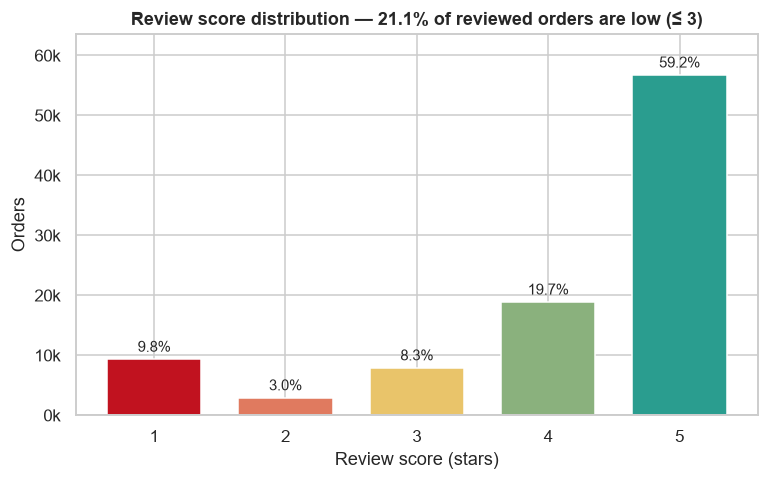

In [6]:
counts = orders_reviewed["review_score"].value_counts().sort_index()
share = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.index, counts.values,
              color=[REVIEW_COLORS[int(s)] for s in counts.index], width=0.72)
for score, pct in zip(counts.index, share.values):
    ax.text(score, counts[score] + 700, f"{pct:.1f}%", ha="center", va="bottom", fontsize=10)

low_share = share.loc[[1, 2, 3]].sum()
ax.set_title(f"Review score distribution — {low_share:.1f}% of reviewed orders are low (≤ 3)")
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("Orders")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
ax.margins(y=0.12)
save_fig(fig, "01_review_score_distribution")
plt.show()

**Takeaway.** Reviews are strongly bimodal: **59%** of orders give 5 stars, but a hard floor of **~10%** give 1 star, and low reviews (≤ 3) total **21.1%** of all reviewed orders — roughly one order in five. This is not a smooth quality gradient with a thin unhappy tail; it is a large, discrete block of dissatisfied customers, which is why the project treats ≤ 3 as a binary problem to explain rather than a score to nudge.

### Chart 2 — Revenue by review-score bucket
**Question (#1):** What is the *revenue at risk* — the R$ tied to low-review orders?

**Revenue at risk = SUM(total_price) WHERE review_score ≤ 3.** Computed on the actual bad-review orders, not estimated from category averages.

saved -> reports\figures\02_revenue_by_review_score.png


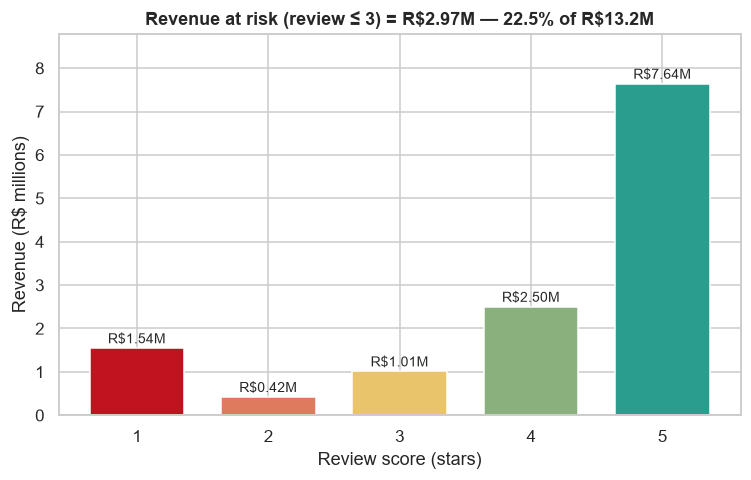

Revenue at risk: R$2,971,338  (22.5% of R$13,220,249)


In [7]:
rev_by_score = orders.dropna(subset=["review_score"]).groupby("review_score")["total_price"].sum()
rev_at_risk = orders.loc[orders["review_score"] <= 3, "total_price"].sum()
total_rev = orders["total_price"].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rev_by_score.index, rev_by_score.values / 1e6,
       color=[REVIEW_COLORS[int(s)] for s in rev_by_score.index], width=0.72)
for score, val in rev_by_score.items():
    ax.text(score, val / 1e6 + 0.05, f"R${val/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

ax.set_title(f"Revenue at risk (review ≤ 3) = R${rev_at_risk/1e6:.2f}M — {rev_at_risk/total_rev*100:.1f}% of R${total_rev/1e6:.1f}M")
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("Revenue (R$ millions)")
ax.margins(y=0.15)
save_fig(fig, "02_revenue_by_review_score")
plt.show()
print(f"Revenue at risk: R${rev_at_risk:,.0f}  ({rev_at_risk/total_rev*100:.1f}% of R${total_rev:,.0f})")

**Takeaway.** Low-review orders carry **R$ 2.97M**, or **22.5%** of the R$ 13.2M in item revenue — slightly *above* their 21.1% share of order count, meaning bad reviews skew marginally toward higher-value orders, not cheap ones. This is the headline number that justifies intervention: a fifth of revenue is attached to customers who are unlikely to return or refer.

### Chart 3 — Delivery gap by review bucket
**Question (#2):** Is late delivery the main culprit? Do low-review orders have longer delivery gaps?

`delivery_gap_days` = actual − estimated delivery date; **positive = late**. Y-axis clipped to [−30, 30] for readability (whiskers extend further).

saved -> reports\figures\03_delivery_gap_by_review_bucket.png


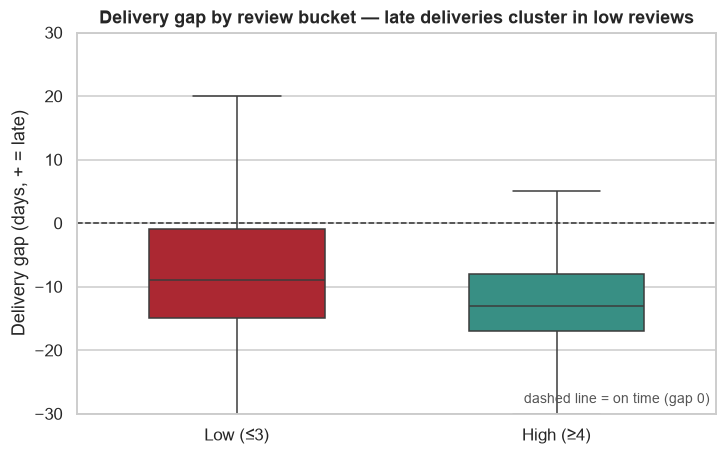

median gap: {'High (≥4)': -13.0, 'Low (≤3)': -9.0}
% actually late: {'High (≥4)': 2.3, 'Low (≤3)': 23.2}


In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
order = ["Low (≤3)", "High (≥4)"]
sns.boxplot(data=orders_reviewed, x="review_bucket", y="delivery_gap_days", order=order,
            hue="review_bucket", palette=BUCKET_COLORS, legend=False, showfliers=False, width=0.55, ax=ax)
ax.axhline(0, color="#333333", lw=1, ls="--")
ax.set_ylim(-30, 30)
ax.text(0.99, 0.02, "dashed line = on time (gap 0)", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=9, color="#555555")
ax.set_title("Delivery gap by review bucket — late deliveries cluster in low reviews")
ax.set_xlabel("")
ax.set_ylabel("Delivery gap (days, + = late)")

med = orders_reviewed.groupby("review_bucket")["delivery_gap_days"].median()
late = orders_reviewed.assign(late=orders_reviewed.delivery_gap_days > 0).groupby("review_bucket")["late"].mean() * 100
save_fig(fig, "03_delivery_gap_by_review_bucket")
plt.show()
print("median gap:", med.round(1).to_dict())
print("% actually late:", late.round(1).to_dict())

**Takeaway.** Both groups usually arrive *early* (Olist pads its estimates), but the gap is clearly worse for low reviews: median −9 days vs −13 days, and critically **23.2% of low-review orders were genuinely late (gap > 0) versus 6.8% of orders overall** — lateness roughly triples in the unhappy group. Delivery is a strong candidate driver, but the large early-delivery overlap says it is *not the whole story*; the Welch t-test in Phase 4 (Q#2) will quantify it.

### Chart 4 — Estimated vs actual delivery date
**Question (#2):** Where do orders fall relative to the promised date, and are the late ones the low-review ones?

Each point is one order (8,000 sampled for legibility). Points **above** the diagonal were delivered *later* than estimated (late).

saved -> reports\figures\04_estimated_vs_actual_delivery.png


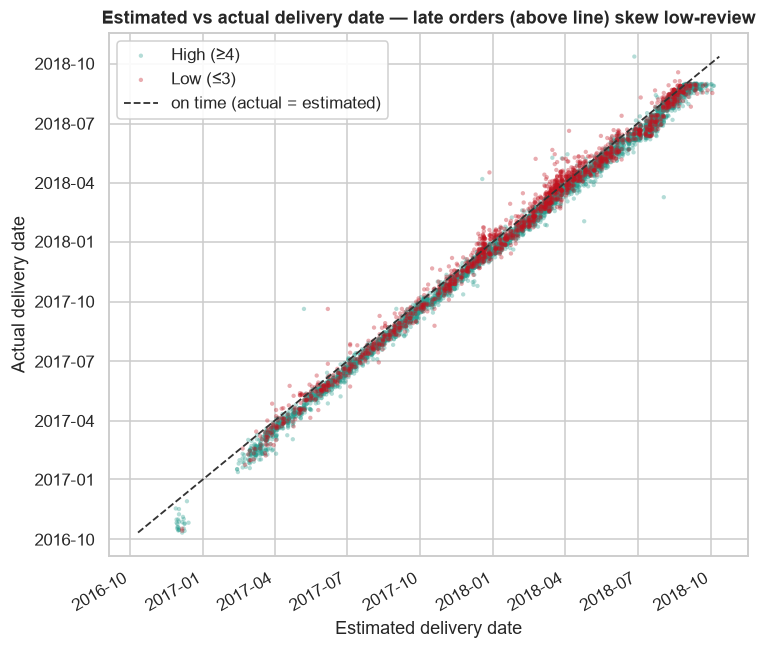

In [9]:
sample = orders_reviewed.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"]).sample(
    n=8000, random_state=7)

fig, ax = plt.subplots(figsize=(7.5, 7))
for bucket in ["High (≥4)", "Low (≤3)"]:
    s = sample[sample["review_bucket"] == bucket]
    ax.scatter(s["order_estimated_delivery_date"], s["order_delivered_customer_date"],
               s=8, alpha=0.35, color=BUCKET_COLORS[bucket], label=bucket, edgecolors="none")

lo = min(sample["order_estimated_delivery_date"].min(), sample["order_delivered_customer_date"].min())
hi = max(sample["order_estimated_delivery_date"].max(), sample["order_delivered_customer_date"].max())
ax.plot([lo, hi], [lo, hi], color="#333333", lw=1.2, ls="--", label="on time (actual = estimated)")
ax.set_title("Estimated vs actual delivery date — late orders (above line) skew low-review")
ax.set_xlabel("Estimated delivery date")
ax.set_ylabel("Actual delivery date")
ax.legend(loc="upper left", framealpha=0.9)
fig.autofmt_xdate()
save_fig(fig, "04_estimated_vs_actual_delivery")
plt.show()

**Takeaway.** The bulk of orders sit **below** the diagonal — delivered before the promised date — confirming padded estimates. The points that break *above* the line are visibly reddened: late deliveries are disproportionately low-review, echoing Chart 3. The vertical scatter also widens over time, hinting the estimate quality drifts, which the monthly view (Chart 7) checks directly.

### Chart 5 — Category volume × review-score mix
**Question (#3):** Where should intervention be prioritised — which high-volume categories skew toward low reviews?

Rows are the **top 15 categories by order volume**; cells show the **share of that category's orders** at each score (rows sum to 100%). The avg score and volume are annotated on the right.

saved -> reports\figures\05_category_review_mix_heatmap.png


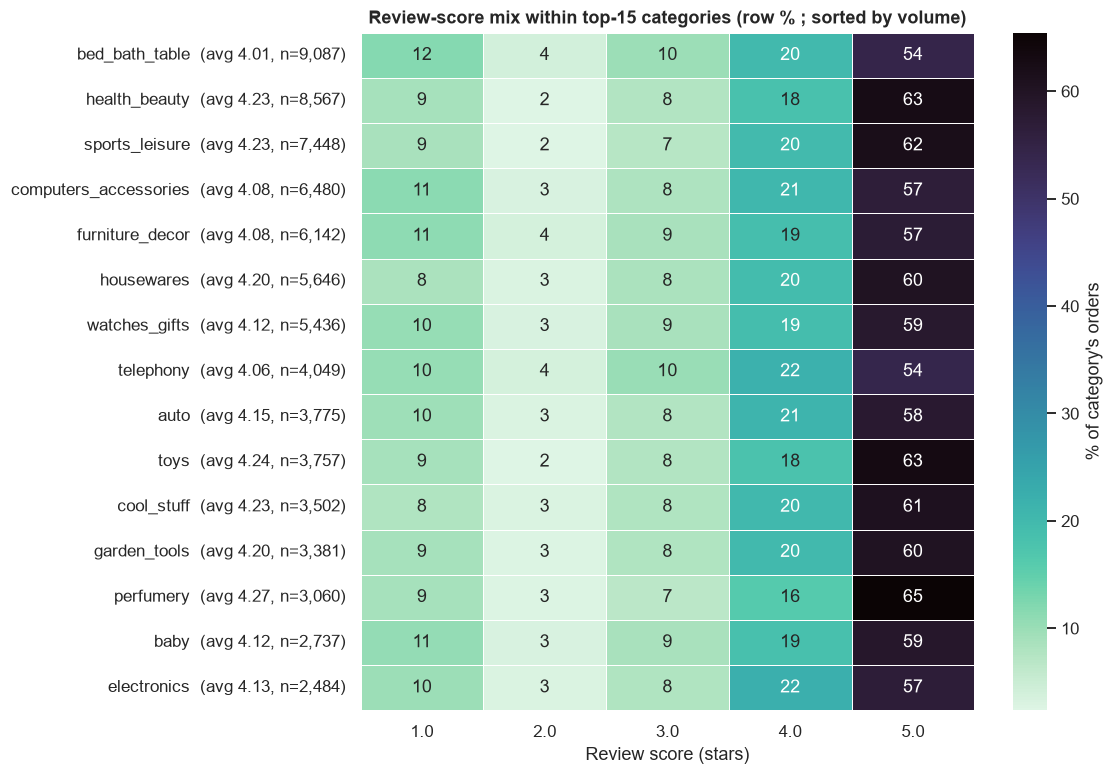

In [10]:
top_cats = orders_reviewed["primary_category"].value_counts().head(15).index.tolist()
sub = orders_reviewed[orders_reviewed["primary_category"].isin(top_cats)]
mix = (sub.groupby(["primary_category", "review_score"]).size()
       .unstack(fill_value=0).reindex(top_cats))
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
avg = sub.groupby("primary_category")["review_score"].mean().reindex(top_cats)
vol = mix.sum(axis=1)
row_labels = [f"{c}  (avg {avg[c]:.2f}, n={vol[c]:,})" for c in top_cats]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(mix_pct, cmap=SEQ, annot=True, fmt=".0f", cbar_kws={"label": "% of category's orders"},
            yticklabels=row_labels, linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Review-score mix within top-15 categories (row % ; sorted by volume)")
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("")
save_fig(fig, "05_category_review_mix_heatmap")
plt.show()

**Takeaway.** Even among high-volume categories the low-review share swings widely: `bed_bath_table` and `computers_accessories` carry a visibly heavier 1–2 star block than `health_beauty` or `watches_gifts` at similar volume, so they combine *scale* with *severity* — exactly the categories a fix should target first. This maps onto the revenue-at-risk ranking (bed_bath_table R$277k, watches_gifts R$244k, health_beauty R$229k) and is the volume/severity signal the ANOVA in Phase 4 tests for significance.

### Chart 6 — State-level review score and delivery gap
**Question (#4):** Are some states structurally worse, and does their delivery track their reviews?

Two panels sharing the state axis (no dual y-axis): avg review score on top, avg delivery gap below. States sorted worst-review first; a more-positive gap = later on average.

saved -> reports\figures\06_state_review_and_delivery.png


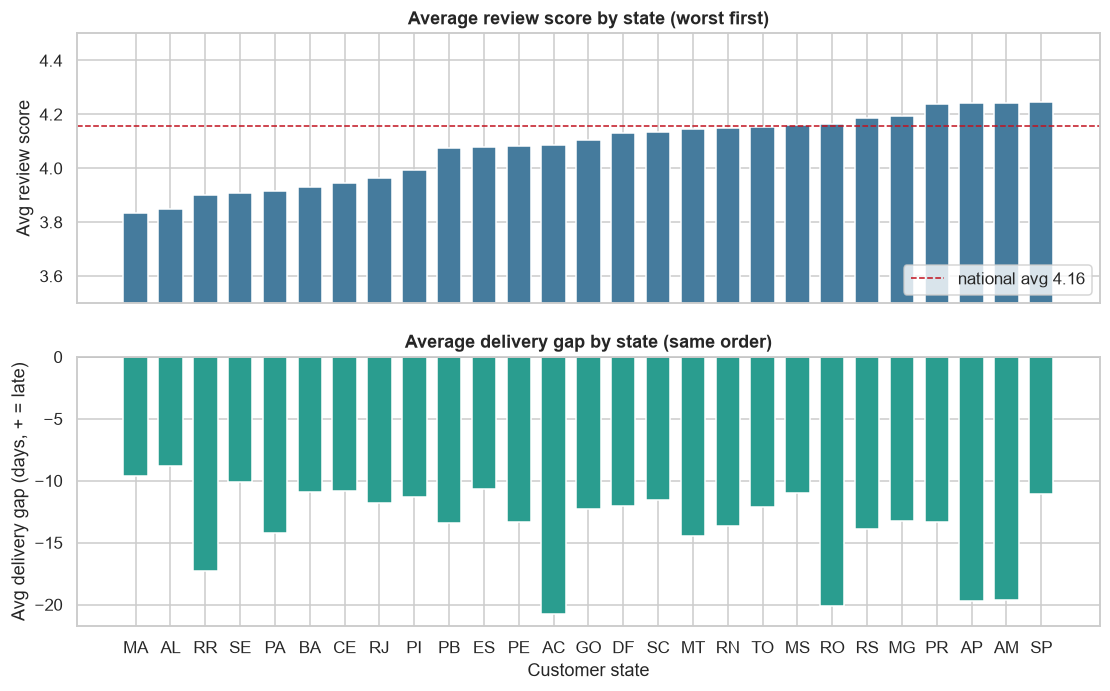

In [11]:
st = (orders_reviewed.groupby("customer_state")
      .agg(avg_review=("review_score", "mean"),
           avg_gap=("delivery_gap_days", "mean"),
           n=("order_id", "size"))
      .sort_values("avg_review"))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.bar(st.index, st["avg_review"], color="#457b9d", width=0.7)
ax1.axhline(orders_reviewed["review_score"].mean(), color="#c1121f", ls="--", lw=1,
            label=f"national avg {orders_reviewed['review_score'].mean():.2f}")
ax1.set_ylim(3.5, 4.5)
ax1.set_ylabel("Avg review score")
ax1.set_title("Average review score by state (worst first)")
ax1.legend(loc="lower right")

colors = ["#c1121f" if g > 0 else "#2a9d8f" for g in st["avg_gap"]]
ax2.bar(st.index, st["avg_gap"], color=colors, width=0.7)
ax2.axhline(0, color="#333333", lw=1)
ax2.set_ylabel("Avg delivery gap (days, + = late)")
ax2.set_title("Average delivery gap by state (same order)")
ax2.set_xlabel("Customer state")
save_fig(fig, "06_state_review_and_delivery")
plt.show()

**Takeaway.** The worst-reviewed states (**MA 3.83, AL 3.85, PA 3.91**) also tend to have the *smallest* early-delivery cushion, so delivery and satisfaction move together across geography — but not perfectly: a few states keep low reviews despite comfortable early delivery, which is the "delivery is NOT the story" quadrant flagged in SQL Q3 and worth a seller-mix look. Note that tiny states (e.g. RR, n=41) are noisy and should not be over-read. Levene's test in Phase 4 (Q#4) checks whether the *variance*, not just the mean, differs between best and worst states.

### Chart 7 — Monthly review score with delivery-time overlay
**Question (#1/#2):** How has the problem trended, and does the review trend track delivery?

Two panels sharing the month axis. Sept 2016 and the tail of Aug 2018 are thin (partial months) and shaded out of interpretation.

saved -> reports\figures\07_monthly_review_and_delivery.png


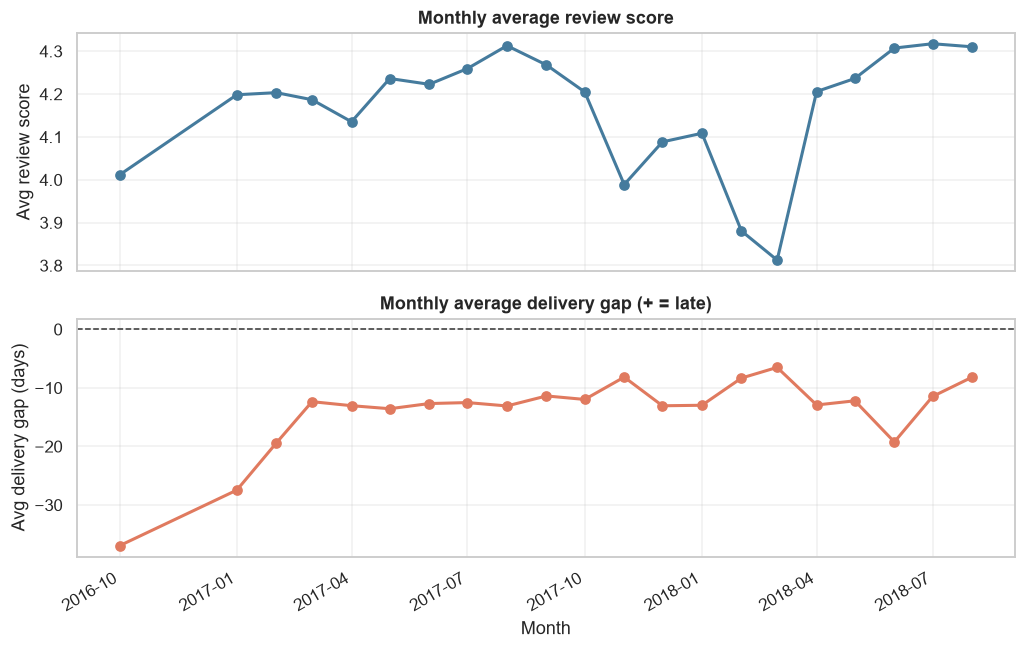

In [12]:
monthly = (orders_reviewed.groupby("order_month")
           .agg(avg_review=("review_score", "mean"),
                avg_gap=("delivery_gap_days", "mean"),
                n=("order_id", "size"))
           .sort_index())
solid = monthly[monthly["n"] >= 200]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.plot(solid.index, solid["avg_review"], marker="o", color="#457b9d", lw=2)
ax1.set_ylabel("Avg review score")
ax1.set_title("Monthly average review score")
ax1.grid(True, alpha=0.3)

ax2.plot(solid.index, solid["avg_gap"], marker="o", color="#e07a5f", lw=2)
ax2.axhline(0, color="#333333", lw=1, ls="--")
ax2.set_ylabel("Avg delivery gap (days)")
ax2.set_title("Monthly average delivery gap (+ = late)")
ax2.set_xlabel("Month")
ax2.grid(True, alpha=0.3)
fig.autofmt_xdate()
save_fig(fig, "07_monthly_review_and_delivery")
plt.show()

**Takeaway.** Average review score is broadly stable around 4.0–4.3, with a sharp **dip to ~3.8 in Feb–Mar 2018**. Notably, the delivery gap stays comfortably *negative* (orders still arriving early) through that same window — so this particular dip is **not** explained by delivery slipping, pointing to a non-logistics cause worth isolating (e.g. a seller, category, or platform issue in that window). The absence of any secular improvement means the low-review problem is structural, not something to wait out.

### Chart 8 — Freight-to-price ratio vs review score
**Question:** Do customers punish orders where freight feels disproportionate to product value?

`freight_ratio = total_freight / total_price`, by review score. Y-axis clipped to [0, 1.5] for readability; Spearman correlation annotated.

saved -> reports\figures\08_freight_ratio_by_review_score.png


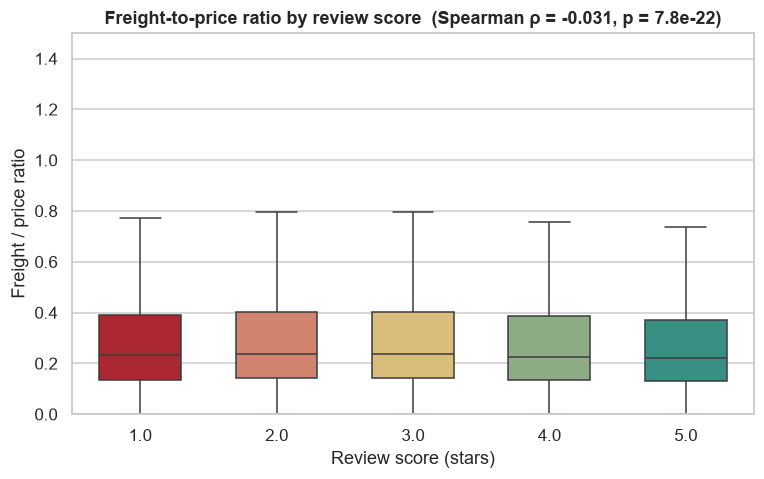

In [13]:
fr = orders_reviewed.dropna(subset=["freight_ratio"])
rho, pval = spearmanr(fr["freight_ratio"], fr["review_score"])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=fr, x="review_score", y="freight_ratio",
            hue="review_score", palette=REVIEW_COLORS, legend=False,
            showfliers=False, width=0.6, ax=ax)
ax.set_ylim(0, 1.5)
ax.set_title(f"Freight-to-price ratio by review score  (Spearman ρ = {rho:.3f}, p = {pval:.1e})")
ax.set_xlabel("Review score (stars)")
ax.set_ylabel("Freight / price ratio")
save_fig(fig, "08_freight_ratio_by_review_score")
plt.show()

**Takeaway.** There is a **weak but statistically significant negative** relationship (Spearman ρ = −0.03, p ≈ 1e−21): higher relative freight nudges reviews down, but the effect size is tiny and the boxplots overlap almost entirely. Freight burden is real at the margin but is a **secondary** driver at best — not where the largest review lift lives. The Spearman test in Phase 4 confirms the direction; the practical conclusion is to not over-invest here.

## 3 · Patterns & problems — EDA findings summary

Raw material for Phase 4 (which test to run) and Phase 5 (findings & recommendations):

1. **Scale of the problem:** 21.1% of reviewed orders (20,188 of 95,824) score ≤ 3 — roughly one in five. Reviews are bimodal (59% five-star, ~10% one-star), so ≤ 3 is best treated as a binary target, not a continuous score.
2. **Revenue at risk = R$ 2.97M (22.5% of R$ 13.2M)**, slightly above the low-review share of *count* — bad reviews skew marginally toward higher-value orders.
3. **Delivery is the leading driver:** low-review orders are genuinely late 23.2% of the time vs 6.8% overall (~3×); median gap −9d vs −13d. But most orders in *both* buckets arrive early, so delivery explains part, not all — sets up the Welch t-test (Q#2).
4. **Estimates are padded:** median delivery gap is negative marketplace-wide; lateness is the exception, which is exactly why it hurts when it happens (Chart 4).
5. **Category matters and concentrates:** `bed_bath_table`, `computers_accessories`, `watches_gifts`, `health_beauty` combine high volume with the largest revenue-at-risk (R$277k / R$244k / R$229k top three) — the priority list for intervention (ANOVA, Q#3).
6. **Geography splits two ways:** worst states (MA, AL, PA) generally have the thinnest delivery cushion, but a few keep low reviews *despite* good delivery — a non-logistics problem to investigate (Levene's test on variance, Q#4).
7. **Trend is structural, not incidental:** review score is broadly flat over 2017–2018 with a sharp dip to ~3.8 in Feb–Mar 2018 that is *not* mirrored by the delivery gap (still early) — that dip has a non-delivery cause worth isolating, and there is no secular improvement to wait for.
8. **Freight burden is a weak secondary effect:** Spearman ρ = −0.03 (significant but tiny) — real at the margin, not a primary lever.

**Handoff to Phase 4:** delivery gap (t-test), category (ANOVA + Tukey), state variance (Levene), installments (chi-square), and freight ratio (Spearman) are all motivated by the patterns above.